## Creating Own Class of Linear_Regression

In [105]:
class MeraLR:

  def __init__(self):
    self.m = 0
    self.b = 0

  def fit(self,X_train , y_train):
    num = 0
    den = 0

    for i in range(80):

      num = num + ( X_train.iloc[i] - X_train.mean() ) * ( y_train.iloc[i] - y_train.mean() )
      den = den + (X_train.iloc[i] - X_train.mean()) ** 2
    self.m = num/den
    self.b = y_train.mean() - self.m *  X_train.mean()

    print(f"The Slope of Line is: {self.m}")
    print(f"The Intercept Value is: {self.b}")

  def predict(self,X_test):
    y_pred = X_test * self.m + self.b
    return y_pred.iloc[0]


## Importing Required Libaries

In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [61]:
df = pd.read_csv("/content/cgpa_placement_100_students.csv")

In [62]:
df = df.drop("Student_ID",axis=1)

<Axes: xlabel='CGPA', ylabel='Package_LPA'>

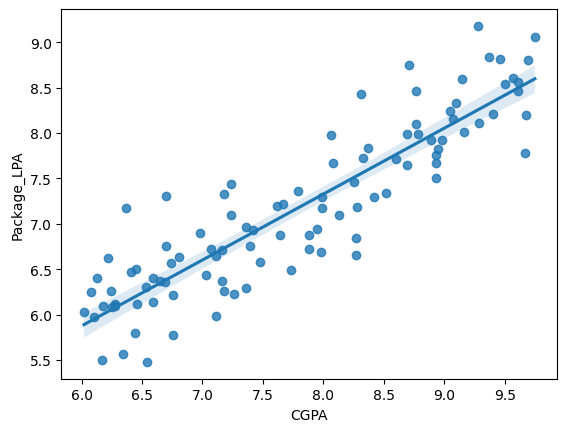

In [63]:
sns.regplot(x=df.iloc[:, 0], y=df.iloc[:, -1])

## Performing Trian_test_Split

In [74]:
X = X = df[["CGPA"]]
y = df.iloc[:,-1]

In [75]:
X_train, X_test, y_train , y_test = train_test_split( X , y , test_size = 0.2 ,
                                                     random_state=42)

In [76]:
X_train.shape

(80, 1)

## Now Creating the Object of Our Own Linear Regression Class

In [106]:
LR = MeraLR()

In [107]:
LR.fit(X_train, y_train)

The Slope of Line is: CGPA    0.732327
dtype: float64
The Intercept Value is: CGPA    1.450536
dtype: float64


In [108]:
LR.predict(X_test)

,83
CGPA,6.020257


## Comparing With Actual Linear Regression Class

In [80]:
from sklearn.linear_model import LinearRegression

In [81]:
model = LinearRegression()

In [82]:
model.fit(X_train,y_train)

LinearRegression()

In [84]:
y_pred = model.predict(X_test)

In [85]:
y_pred[0]

np.float64(6.02025675324798)

In [104]:
model.coef_

array([0.73232705])

## Calculate the Regression Metrics

In [110]:
print(f"Mean Absolute Error (MAE) : {mean_absolute_error(y_test,y_pred)}")
print(f"Mean Squared Error (MSE) : {mean_squared_error(y_test,y_pred)}")
print(f"Root Mean Squared Error (MSE) : {np.sqrt(mean_squared_error(y_test,y_pred))}")
print(f"R2 Score (R2) : {r2_score(y_test,y_pred)}")


Mean Absolute Error (MAE) : 0.26528978172083006
Mean Squared Error (MSE) : 0.13200415626923606
Root Mean Squared Error (MSE) : 0.3633237623239582
R2 Score (R2) : 0.839166964388196
